# 11. #
 In this problem we will investigate the t-statistic for the null hypothesis
H0 : # = 0 in simple linear regression without an intercept. To
begin, we generate a predictor x and a response y as follows.

In [64]:
import numpy as np
import pandas as pd
from matplotlib.pyplot import subplots
import statsmodels.api as sm
from ISLP.models import (ModelSpec as MS,
                         poly,
                         summarize)

In [65]:
rng = np.random.default_rng(seed=1)
x = rng.normal(size=100)
y = 2 * x + rng.normal(size=100)

(a) Perform a simple linear regression of y onto x, without an intercept.
Report the coefficient estimate ˆ β, the standard error of
this coefficient estimate, and the t-statistic and p-value associated
with the null hypothesis H0 : β = 0. Comment on these
results. (You can perform regression without an intercept using
the keywords argument intercept=False to ModelSpec().)

In [66]:
df = pd.DataFrame({'x':x, 'y':y})
X = MS('x',intercept=False).fit_transform(df)
resultados = sm.OLS(y, X).fit()
print('R2:', resultados.rsquared)
print('p-valor:', resultados.pvalues)
summarize(resultados).T


R2: 0.7425605855144493
p-valor: x    6.231546e-31
dtype: float64


,x
coef,1.9762
std err,0.1170
t,16.8980
P>|t|,0.0000


Estatística t possui um valor alto e seu p-valor está baixo o que indica que podemos descartar a hipótese nula para o preditor.

(b) Now perform a simple linear regression of x onto y without an
intercept, and report the coefficient estimate, its standard error,
and the corresponding t-statistic and p-values associated with
the null hypothesis H0 : β = 0. Comment on these results.

In [67]:
resultados1 = sm.OLS(x, MS('y', intercept=False).fit_transform(df)).fit()
print('R2:', resultados1.rsquared)
print('p-valor:', resultados1.pvalues)
summarize(resultados1).T

R2: 0.7425605855144495
p-valor: y    6.231546e-31
dtype: float64


,y
coef,0.3757
std err,0.0220
t,16.8980
P>|t|,0.0000


Estatistica T, R2  e p-valor idênticos, esse modelo tem um desvio padrão menor

(c) What is the relationship between the results obtained in (a) and
(b)?

Os modelos tem estatísticas T, p e R2 idênticas, a diferença está no coeficiente e erro padrão, o valor de Y do dataset foi gerado com o dobro de x mais um ruído, o modelo b tem um valor de desvio padrão menor pois seus valores tem um alcance/variância menor, porém proporcionalmente se equivalem pois o R2 é igual em ambos os casos.

(d) For the regression of Y onto X without an intercept, the t statistic
for H0 :β = 0 takes the form `β/SE(β)`, where β is
given by (3.38), Show algebraically, and confirm numerically
in R, that the t-statistic can be written as:
√((n-1) (Σxiyi)) / √((Σxi²) (Σyi²) - (Σ(xiyi)²))

t = β/SE(β) = √((n-1) (Σxiyi)) / √((Σxi²) (Σyi²) - (Σ(xiyi)²))
 
SE(β) = √(Σ(yixiβ)²/(n-1)(Σxi²))

Decompondo o numerador Σ(yi-xiβ)², fazendo o produto notável Σ(yi² -2yixiβ + xi²β²)

Isolando as somas dos termos: `Σ(yi²) -2βΣ(yixi) + β²Σ(xi²)`

β = Σ(xiyi)/Σ(xi²)

Substituir β na fórmula anterior:

Σ(yi²) -2`(Σ(xiyi)/Σ(xi)²)` Σ(yixi) + `(Σ(xiyi)/Σ(xi²))`² Σ(xi²)

Multiplicando β por Σ(yixi); elevando o último termo e simplificando:

Σ(yi²) -2`(Σ(xiyi)²/Σ(xi)²)` + `Σ(xiyi)²/(Σ(xi²)` ~~Σ(xi²)~~) ~~Σ(xi²)~~ 

Σ(yi²) `-2Σ(xiyi)²/(Σ(xi)²) + Σ(xiyi)²/(Σ(xi²))`

realizando a soma : 

Σ(yi²) - Σ(xiyi)²/Σ(xi)²

termo final: `Σ(yi²) - Σ(xiyi)²/Σ(xi)²`

Substituindo na fórmula original SE(β):

SE(β) = √((`Σ(yi²) - (Σ(xiyi)²/Σ(xi)²)`)/((n-1)(Σxi²)))

Voltando a fórmula de t β/SE(β) e substituindo os valores:

t = (Σ(xiyi)/Σ(xi²)) / √((Σ(yi²) - (Σ(xiyi)²/Σ(xi)²))/((n-1)(Σxi²)))

Adicionando  √(n-1), multiplicando numerador e denominador para simplificar:

`√(n-1)` (Σ(xiyi)/Σ(xi²)) / √(~~`√(n-1)`~~ (Σ(yi²) - (Σ(xiyi)²/Σ(xi)²))/(~~(n-1)~~(Σxi²)))

√(n-1) (Σ(xiyi)/Σ(xi²)) / √((Σ(yi²) - (Σ(xiyi)²/Σ(xi)²))/((Σxi²)))

Levando Σ(xi²) do numerador para o numerador:

√(n-1) (Σ(xiyi)/~~Σ(xi²)~~) / `Σ(xi²)` √((Σ(yi²) - (Σ(xiyi)²/Σ(xi)²))/((Σxi²)))

levar `Σ(xi²)` para dentro da raiz, tem que elevar ao quadrado

√(n-1) (Σ(xiyi)) / √(`Σ(xi²)²`(Σ(yi²) - (Σ(xiyi)²/Σ(xi)²))/((Σxi²)))

removendo divisão pois agora temos um termo para simplificar

√(n-1) (Σ(xiyi)) / √(`Σ(xi²)` ~~`Σ(xi²)`~~ (Σ(yi²) - (Σ(xiyi)²/Σ(xi)²))/~~((Σxi²))~~)

√(n-1) (Σ(xiyi)) / √(Σ(xi²) (Σ(yi²) - (Σ(xiyi)²/Σ(xi)²))/~~((Σxi²))~~)

√(n-1) (Σ(xiyi)) / √(Σ(xi²) (Σ(yi²) - (Σ(xiyi)²/Σ(xi)²)))

Multiplicando Σ(xi²) por cada termo dentro do parenteses

√(n-1) (Σ(xiyi)) / √((`Σ(xi²)`Σ(yi²) - `Σ(xi²)`(Σ(xiyi)²/Σ(xi)²)))

Simplificando:

√(n-1) (Σ(xiyi)) / √((Σ(xi²)Σ(yi²) - ~~`Σ(xi²)`~~(Σ(xiyi)²/~~Σ(xi)²~~)))

`√(n-1) (Σ(xiyi)) / √((Σ(xi²)Σ(yi²) - (Σ(xiyi)²)))`

(e) Using the results from (d), argue that the t-statistic for the regression
of y onto x is the same as the t-statistic for the regression
of x onto y.

no caso de X em Y e Y em X, a estatistica T tem o mesmo resultado pois, o numerador e demoninador terão os mesmos valores, a soma do produto deles serão iguais, a soma isolada de cada termo ao quadrado, produto delas também terão os mesmos valores, só invertem a posição.

(f) In R, show that when regression is performed with an intercept,
the t-statistic for H0 : #1 = 0 is the same for the regression of y
onto x as it is for the regression of x onto y.

In [68]:
print(summarize(sm.OLS(y, MS('x').fit_transform(df)).fit()).T)
print(summarize(sm.OLS(x, MS('y').fit_transform(df)).fit()).T)


         intercept        x
coef        -0.076   1.9686
std err      0.101   0.1180
t           -0.756  16.7340
P>|t|        0.451   0.0000
         intercept        y
coef        0.0095   0.3763
std err     0.0440   0.0220
t           0.2160  16.7340
P>|t|       0.8290   0.0000


# 12. # 
This problem involves simple linear regression without an intercept.
(a) Recall that the coefficient estimate β for the linear regression of
Y onto X without an intercept is given by (3.38). Under what
circumstance is the coefficient estimate for the regression of X
onto Y the same as the coefficient estimate for the regression of
Y onto X?

Quando a variância entre eles forem iguais.

(b) Generate an example in Python with n = 100 observations in
which the coefficient estimate for the regression of X onto Y
is different from the coefficient estimate for the regression of Y
onto X.

In [69]:
x = rng.normal(size=100)
y = x **2 - rng.normal(size=100)
df = pd.DataFrame({'x':x, 'y':y})
print(summarize(sm.OLS(y,MS('x', intercept=False).fit_transform(df)).fit()).T)
print(summarize(sm.OLS(x,MS('y', intercept=False).fit_transform(df)).fit()).T)

              x
coef    -0.1116
std err  0.2010
t       -0.5550
P>|t|    0.5800
              y
coef    -0.0278
std err  0.0500
t       -0.5550
P>|t|    0.5800


(c) Generate an example in Python with n = 100 observations in
which the coefficient estimate for the regression of X onto Y is
the same as the coefficient estimate for the regression of Y onto
X.

In [70]:
x = rng.normal(size=100)
y = x.copy()
y.sort()
df = pd.DataFrame({'x':x,'y':y})
print(summarize(sm.OLS(y,MS('x', intercept=False).fit_transform(df)).fit()).T)
print(summarize(sm.OLS(x,MS('y', intercept=False).fit_transform(df)).fit()).T)



              x
coef     0.1012
std err  0.1000
t        1.0120
P>|t|    0.3140
              y
coef     0.1012
std err  0.1000
t        1.0120
P>|t|    0.3140


# 13. #
In this exercise you will create some simulated data and will fit simple
linear regression models to it. Make sure to use the default random
number generator with seed set to 1 prior to starting part (a) to
ensure consistent results.

(a) Using the normal() method of your random number generator,
create a vector, x, containing 100 observations drawn from a
N(0, 1) distribution. This represents a feature, X.

In [71]:
x = rng.normal(size=100)

(b) Using the normal() method, create a vector, eps, containing 100
observations drawn from a N(0, 0.25) distribution—a normal
distribution with mean zero and variance 0.25.

In [72]:
eps = rng.normal(loc=0, scale=0.25, size=100)

(c) Using x and eps, generate a vector y according to the model
`Y = −1 + 0.5X + ` . (3.39)
What is the length of the vector y? What are the values of β0
and β1 in this linear model?

In [73]:
y = -1 + 0.5*x + eps

#β0 = -1
#β1 = 0.5
print('Comprimento de y:', len(y))

Comprimento de y: 100


(d) Create a scatterplot displaying the relationship between x and
y. Comment on what you observe.

Text(0, 0.5, 'Y')

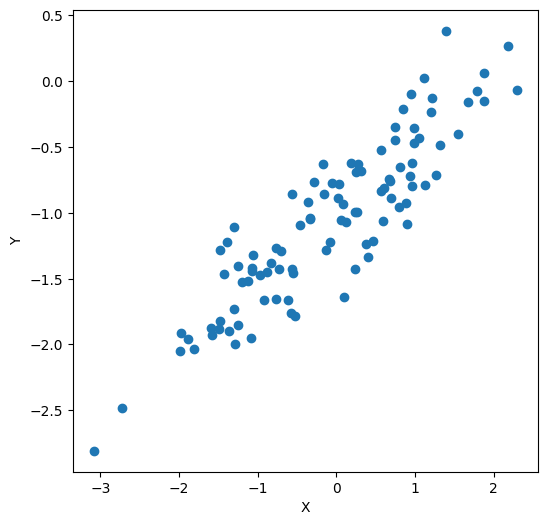

In [74]:
ax = subplots(figsize=(6,6))[1]
ax.scatter(x,y)
ax.set_xlabel('X')
ax.set_ylabel('Y')


Uma certa forma linear, o começo tem uma dispersão entre os pontos, forma crescente

(e) Fit a least squares linear model to predict y using x. Comment
on the model obtained. How do ^β0 and ^β1 compare to β0 and
β1?

In [75]:
df = pd.DataFrame({'x':x, 'y':y})
resultados_13_e = sm.OLS(y, MS('x').fit_transform(df)).fit()
print('Valor de β0 original - 1, valor ^β0:', resultados_13_e.params['intercept'])
print('Diferença entre valores:', -1 -resultados_13_e.params['intercept'])
print('Valor de β1 original 0.5, valor ^β1:', resultados_13_e.params['x'])
print('Diferença entre valores:', 0.5 -resultados_13_e.params['x'])
resultados_13_e.summary()

Valor de β0 original - 1, valor ^β0: -1.0230562402844774
Diferença entre valores: 0.02305624028447739
Valor de β1 original 0.5, valor ^β1: 0.49912226014684236
Diferença entre valores: 0.0008777398531576441


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.807
Model:                            OLS   Adj. R-squared:                  0.805
Method:                 Least Squares   F-statistic:                     409.3
Date:                Mon, 18 May 2026   Prob (F-statistic):           9.15e-37
Time:                        12:24:18   Log-Likelihood:                -11.358
No. Observations:                 100   AIC:                             26.72
Df Residuals:                      98   BIC:                             31.93
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
intercept     -1.0231      0.027    -37.253      0.000      -1.078      -0.969
x              0.4991      0.025     20.232      0.000       0.450       0.548
==============================================================================
Omnibus:                        0.190   Durbin-Watson:                   1.880
Prob(Omnibus):                  0.910   Jarque-Bera (JB):                0.367
Skew:                           0.049   Prob(JB):                        0.832
Kurtosis:                       2.720   Cond. No.                         1.14
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

(f) Display the least squares line on the scatterplot obtained in (d).
Draw the population regression line on the plot, in a different
color. Use the legend() method of the axes to create an appropriate
legend.

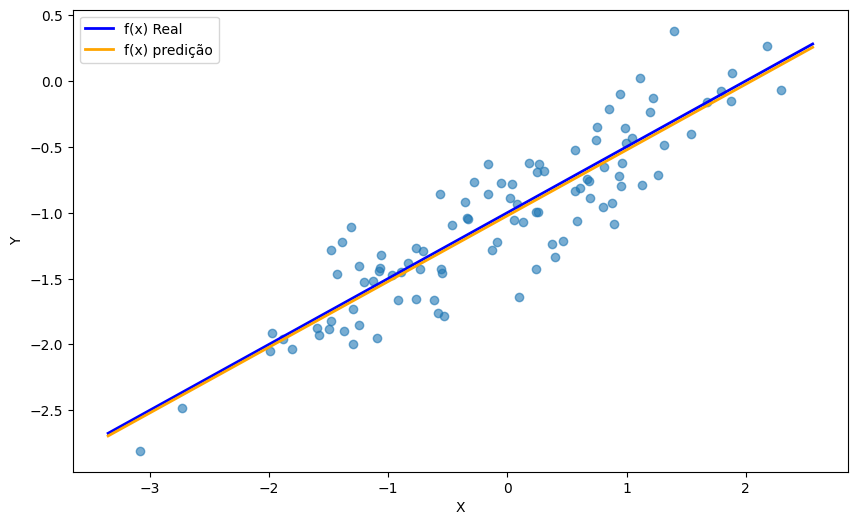

In [76]:
def plot_comparacao_real_predicao(ax, r):
        xlim = ax.get_xlim()
        ylim = [-1 +0.5*xlim[0], -1 +0.5*xlim[1]]
        ax.plot(xlim,ylim, linewidth=2, color='blue', label='f(x) Real')
        ylim = [r.params['intercept'] + r.params['x']*xlim[0],
                r.params['intercept'] + r.params['x']*xlim[1]]
        ax.plot(xlim,ylim, linewidth=2, color='orange', label='f(x) predição')
        ax.legend(loc='upper left')

ax = subplots(figsize=(10,6))[1]
ax.scatter(x,y, alpha=0.6)
ax.set_xlabel('X')
ax.set_ylabel('Y')

plot_comparacao_real_predicao(ax, resultados_13_e)

(g) Now fit a polynomial regression model that predicts y using x
and x2. Is there evidence that the quadratic term improves the
model fit? Explain your answer.

In [77]:
resultados_13_g = sm.OLS(y, MS(['x', poly('x',degree=2)]).fit_transform(df)).fit()
resultados_13_g.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.807
Model:                            OLS   Adj. R-squared:                  0.803
Method:                 Least Squares   F-statistic:                     202.6
Date:                Mon, 18 May 2026   Prob (F-statistic):           2.33e-35
Time:                        12:24:19   Log-Likelihood:                -11.356
No. Observations:                 100   AIC:                             28.71
Df Residuals:                      97   BIC:                             36.53
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
========================================================================================
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
intercept               -1.0233      0.028    -37.078      0.000      -1.078      -0.969
x                        0.4958      0.025     20.159      0.000       0.447       0.545
poly(x, degree=2)[0]     0.0369      0.002     16.450      0.000       0.032       0.041
poly(x, degree=2)[1]    -0.0192      0.275     -0.070      0.945      -0.565       0.527
==============================================================================
Omnibus:                        0.161   Durbin-Watson:                   1.880
Prob(Omnibus):                  0.923   Jarque-Bera (JB):                0.337
Skew:                           0.046   Prob(JB):                        0.845
Kurtosis:                       2.731   Cond. No.                     3.30e+16
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The smallest eigenvalue is 1.17e-31. This might indicate that there are
strong multicollinearity problems or that the design matrix is singular.
"""

In [78]:
from statsmodels.stats.anova import anova_lm
anova_lm(resultados_13_e, resultados_13_g)

,df_resid,ssr,df_diff,ss_diff,F,Pr(>F)
0,98.0,7.348221,0.0,NaN,NaN,NaN
1,97.0,7.347854,1.0,0.000368,0.004853,0.944603


o novo preditor não melhora o modelo, F baixo e o p-value muito acima de 0.05

(h) Repeat (a)–(f) after modifying the data generation process in
such a way that there is less noise in the data. The model (3.39)
should remain the same. You can do this by decreasing the variance
of the normal distribution used to generate the error term
" in (b). Describe your results.

Text(0.5, 0, 'x')

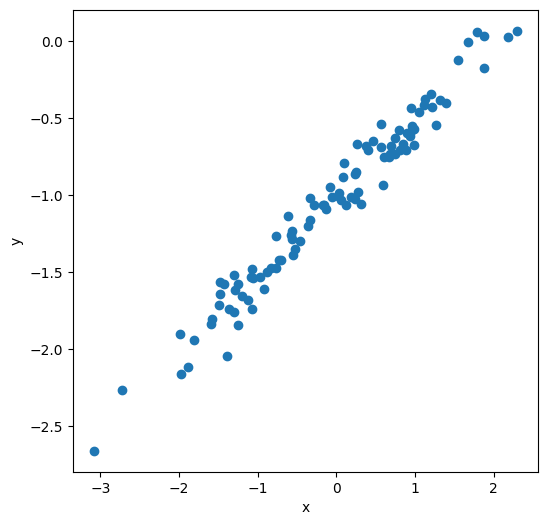

In [79]:
eps = rng.normal(loc=0, scale=0.10, size=100)
y = -1 +0.5*x + eps
#esperado menor variabilidade entre os pontos
ax = subplots(figsize=(6,6))[1]
ax.scatter(x,y)
ax.set_ylabel('y')
ax.set_xlabel('x')

In [80]:
df = pd.DataFrame({'x':x, 'y':y})
resultados_13_h = sm.OLS(y, MS('x').fit_transform(df)).fit()

print('Valor de β0 original - 1, valor ^β0:', resultados_13_h.params['intercept'])
print('Diferença entre valores:', -1 -resultados_13_h.params['intercept'])
print('Valor de β1 original 0.5, valor ^β1:', resultados_13_h.params['x'])
print('Diferença entre valores:', 0.5 -resultados_13_h.params['x'])
resultados_13_h.summary()

Valor de β0 original - 1, valor ^β0: -1.0187322998637112
Diferença entre valores: 0.018732299863711166
Valor de β1 original 0.5, valor ^β1: 0.5044606070331659
Diferença entre valores: -0.004460607033165864


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.965
Model:                            OLS   Adj. R-squared:                  0.965
Method:                 Least Squares   F-statistic:                     2708.
Date:                Mon, 18 May 2026   Prob (F-statistic):           3.39e-73
Time:                        12:24:19   Log-Likelihood:                 82.041
No. Observations:                 100   AIC:                            -160.1
Df Residuals:                      98   BIC:                            -154.9
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
intercept     -1.0187      0.011    -94.396      0.000      -1.040      -0.997
x              0.5045      0.010     52.034      0.000       0.485       0.524
==============================================================================
Omnibus:                        0.305   Durbin-Watson:                   1.819
Prob(Omnibus):                  0.859   Jarque-Bera (JB):                0.353
Skew:                          -0.127   Prob(JB):                        0.838
Kurtosis:                       2.859   Cond. No.                         1.14
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

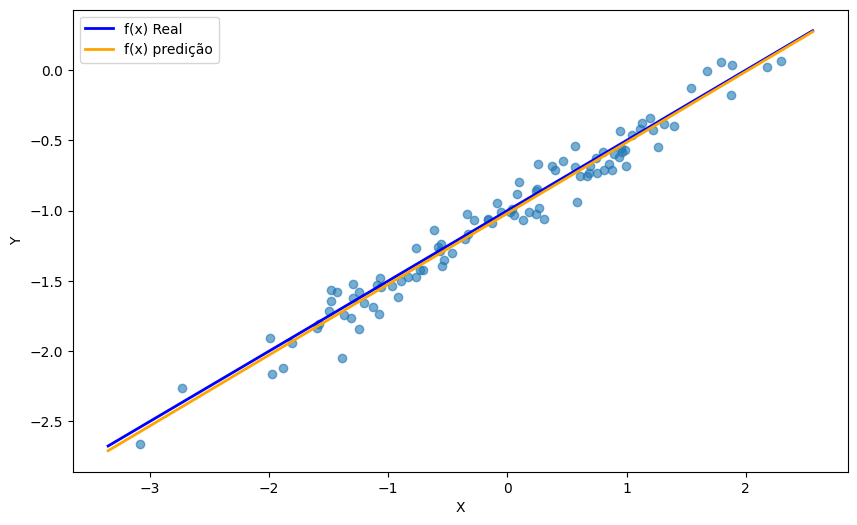

In [81]:
ax = subplots(figsize=(10,6))[1]
ax.scatter(x,y, alpha=0.6)
ax.set_xlabel('X')
ax.set_ylabel('Y')

plot_comparacao_real_predicao(ax, resultados_13_h)

Como esperado com a redução do erro o modelo melhorou.

(i) Repeat (a)–(f) after modifying the data generation process in
such a way that there is more noise in the data. The model
(3.39) should remain the same. You can do this by increasing
the variance of the normal distribution used to generate the
error term " in (b). Describe your results.

eps = rng.normal(loc=0, scale=0.8, size=100)
y = -1 +0.5*x + eps
#esperado menor variabilidade entre os pontos
ax = subplots(figsize=(6,6))[1]
ax.scatter(x,y)
ax.set_ylabel('y')
ax.set_xlabel('x')

In [82]:
df = pd.DataFrame({'x':x, 'y':y})
resultados_13_i = sm.OLS(y, MS('x').fit_transform(df)).fit()

print('Valor de β0 original - 1, valor ^β0:', resultados_13_i.params['intercept'])
print('Diferença entre valores:', -1 -resultados_13_i.params['intercept'])
print('Valor de β1 original 0.5, valor ^β1:', resultados_13_i.params['x'])
print('Diferença entre valores:', 0.5 -resultados_13_i.params['x'])
resultados_13_i.summary()

Valor de β0 original - 1, valor ^β0: -1.0187322998637112
Diferença entre valores: 0.018732299863711166
Valor de β1 original 0.5, valor ^β1: 0.5044606070331659
Diferença entre valores: -0.004460607033165864


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.965
Model:                            OLS   Adj. R-squared:                  0.965
Method:                 Least Squares   F-statistic:                     2708.
Date:                Mon, 18 May 2026   Prob (F-statistic):           3.39e-73
Time:                        12:24:19   Log-Likelihood:                 82.041
No. Observations:                 100   AIC:                            -160.1
Df Residuals:                      98   BIC:                            -154.9
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
intercept     -1.0187      0.011    -94.396      0.000      -1.040      -0.997
x              0.5045      0.010     52.034      0.000       0.485       0.524
==============================================================================
Omnibus:                        0.305   Durbin-Watson:                   1.819
Prob(Omnibus):                  0.859   Jarque-Bera (JB):                0.353
Skew:                          -0.127   Prob(JB):                        0.838
Kurtosis:                       2.859   Cond. No.                         1.14
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

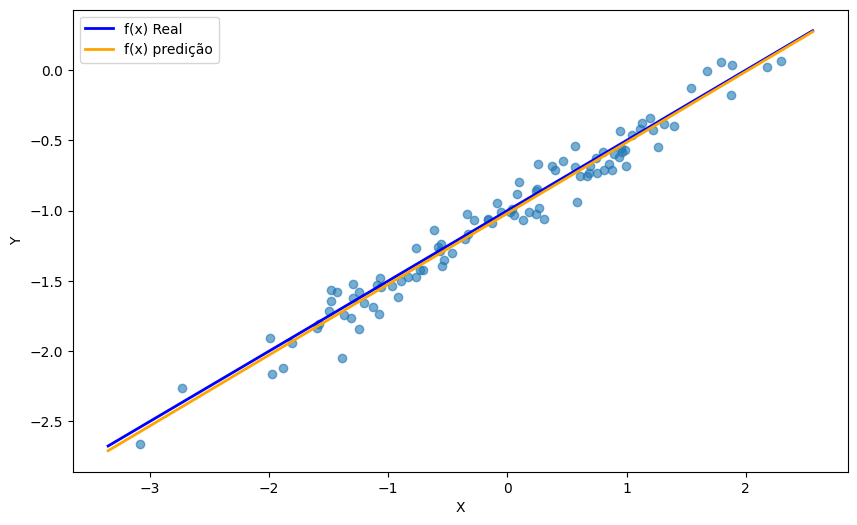

In [83]:
ax = subplots(figsize=(10,6))[1]
ax.scatter(x,y, alpha=0.6)
ax.set_xlabel('X')
ax.set_ylabel('Y')

plot_comparacao_real_predicao(ax, resultados_13_i)

Como esperado o aumento do erro fez o resultado do modelo piorar.
O interessante de se notar é que a diferença da função real da modelada não muda bastante, está bem proximo da real, mas como o erro global aumenta os resultados pioram, conseguimos encontrar hipóteses ótimas, porém o erro intrínseco do modelo que está trazendo a diferença entre eles

(j) What are the confidence intervals for β0 and β1 based on the
original data set, the noisier data set, and the less noisy data
set? Comment on your results.

In [84]:
print('Intervalo de confiança modelo original:\n',resultados_13_e.conf_int())
print('\nIntervalo de confiança modelo baixo ruído:\n',resultados_13_h.conf_int())
print('\nIntervalo de confiança modelo alto ruído:\n',resultados_13_i.conf_int())

Intervalo de confiança modelo original:
                   0         1
intercept -1.077554 -0.968558
x          0.450166  0.548079

Intervalo de confiança modelo baixo ruído:
                   0         1
intercept -1.040149 -0.997316
x          0.485222  0.523700

Intervalo de confiança modelo alto ruído:
                   0         1
intercept -1.040149 -0.997316
x          0.485222  0.523700


Como o intervalo de confiança é cálculado com o erro padrão do coeficiente SE(β), quanto maior o erro maior será o intervalo de confiança

# 14. #
This problem focuses on the collinearity problem.
(a) Perform the following commands in Python:

The last line corresponds to creating a linear model in which y is
a function of x1 and x2. Write out the form of the linear model.
What are the regression coefficients?

In [85]:
rng = np.random.default_rng(seed=10)
x1 = rng.uniform(0, 1, size=100)
x2 = 0.5 * x1 + rng.normal(size=100) / 10
y = 2 + 2 * x1 + 0.3 * x2 + rng.normal(size=100)

β0(Intercepto): 2

β1: 2

β2: 0.3


(b) What is the correlation between x1 and x2? Create a scatterplot
displaying the relationship between the variables.

Text(0, 0.5, 'x2')

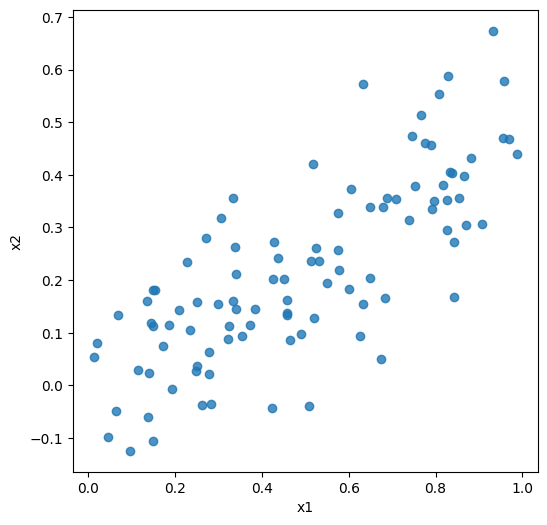

In [86]:
ax = subplots(figsize=(6,6))[1]
ax.scatter(x1, x2, alpha=0.8)
ax.set_xlabel('x1')
ax.set_ylabel('x2')

X2 é a metade de x1 mais um ruído, possuem correlação, há um formato linear porém bem disperso

(c) Using this data, fit a least squares regression to predict y using
x1 and x2. Describe the results obtained. What are ˆ β0, ˆ β1, and
ˆ β2? How do these relate to the true β0, β1, and β2? Can you
reject the null hypothesis H0 : β1 = 0? How about the null
hypothesis H0 : β2 = 0?

In [87]:
df = pd.DataFrame({'x1':x1, 'x2':x2, 'y':y})
resultados_14_c = sm.OLS(y,MS(['x1','x2']).fit_transform(df)).fit()
resultados_14_c.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.291
Model:                            OLS   Adj. R-squared:                  0.276
Method:                 Least Squares   F-statistic:                     19.89
Date:                Mon, 18 May 2026   Prob (F-statistic):           5.76e-08
Time:                        12:24:19   Log-Likelihood:                -130.62
No. Observations:                 100   AIC:                             267.2
Df Residuals:                      97   BIC:                             275.1
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      1.9579      0.190     10.319      0.000       1.581       2.334
x1             1.6154      0.527      3.065      0.003       0.569       2.661
x2             0.9428      0.831      1.134      0.259      -0.707       2.592
==============================================================================
Omnibus:                        0.051   Durbin-Watson:                   1.964
Prob(Omnibus):                  0.975   Jarque-Bera (JB):                0.041
Skew:                          -0.036   Prob(JB):                        0.979
Kurtosis:                       2.931   Cond. No.                         11.9
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

O coeficiente do intercepto β0 ficou próximo da função real, os demias ficaram ­± 0.4 distante de seu valor real.

Pelo p-valor de β1 de 0.003 podemos descartar a hipótese nula H0:β1=0.

Pelo p-valor de β2 de 0.259 e estatística t próxima de 1, podemos considerar a hipótese nula H0:β2=0

(d) Now fit a least squares regression to predict y using only x1.
Comment on your results. Can you reject the null hypothesis
H0 : β1 = 0?

In [88]:
resultados_14_d = sm.OLS(y, MS(['x1']).fit_transform(df)).fit()
print('R2:', resultados_14_d.rsquared)
summarize(resultados_14_d).T

R2: 0.2814635507431502


,intercept,x1
coef,1.9371,2.0771
std err,0.1890,0.3350
t,10.2420,6.1960
P>|t|,0.0000,0.0000


Pelo p-valor de β1 podemos descartar a hipótese nula H0:β1=0.

O coeficiente de β0 β1 ficaram mais próximos da função Real ± 0.07 de diferença

(e) Now fit a least squares regression to predict y using only x2.
Comment on your results. Can you reject the null hypothesis
H0 : β1 = 0?

In [89]:
resultados_14_e = sm.OLS(y, MS(['x2']).fit_transform(df)).fit()
print('R2:', resultados_14_e.rsquared)
summarize(resultados_14_e).T

R2: 0.2221764036359425


,intercept,x2
coef,2.3239,2.9103
std err,0.1540,0.5500
t,15.1240,5.2910
P>|t|,0.0000,0.0000


Pelo p-valor de β1 podemos descartar a hipótese nula H0:β1=0.

Modelo teve um pior resultado, como na função real seu peso para Y é menor, o coeficiente dele e do intercepto tiveram aumentos substanciais.

(f) Do the results obtained in (c)–(e) contradict each other? Explain
your answer.

Não, o modelo (e) se mostra significante por causa da correlação com x1 e não por causalidade, o que x2 explica é devido a sua correlação com x1.

(g) Suppose we obtain one additional observation, which was unfortunately
mismeasured. We use the function np.concatenate() to add
this additional observation to each of x1, x2 and y. 

In [90]:
x1 = np.concatenate([x1, [0.1]])
x2 = np.concatenate([x2, [0.8]])
y = np.concatenate([y, [6]])

Re-fit the linear models from (c) to (e) using this new data. What
effect does this new observation have on the each of the models?
In each model, is this observation an outlier? A high-leverage
point? Both? Explain your answers.

R2: 0.29162832021142115
         intercept      x1      x2
coef        2.0618  0.8575  2.2663
std err     0.1920  0.4660  0.7050
t          10.7200  1.8380  3.2160
P>|t|       0.0000  0.0690  0.0020


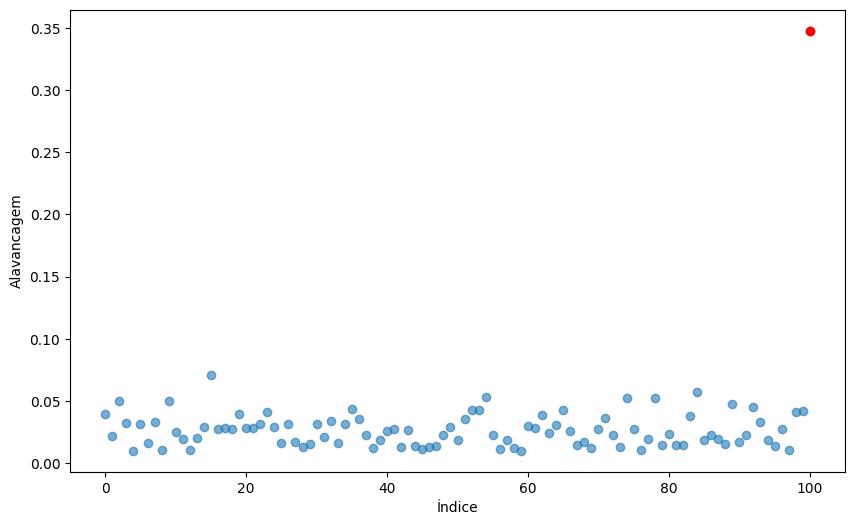

In [91]:
df = pd.DataFrame({'x1':x1, 'x2':x2, 'y':y})
resultados_14_c_g = sm.OLS(y,MS(['x1','x2']).fit_transform(df)).fit()
print('R2:', resultados_14_c_g.rsquared)
print(summarize(resultados_14_c_g).T)

def plot_hat_matrix_diag(res):
    infl = res.get_influence()
    indice_outlier = 100
    ax = subplots(figsize=(10, 6))[1]
    ax.scatter(np.arange(res.nobs), infl.hat_matrix_diag, alpha=0.6)
    ax.scatter(np.arange(res.nobs)[indice_outlier], infl.hat_matrix_diag[indice_outlier], color='red')
    ax.set_xlabel('Índice')
    ax.set_ylabel('Alavancagem')
    np.argmax(infl.hat_matrix_diag)

plot_hat_matrix_diag(resultados_14_c_g)


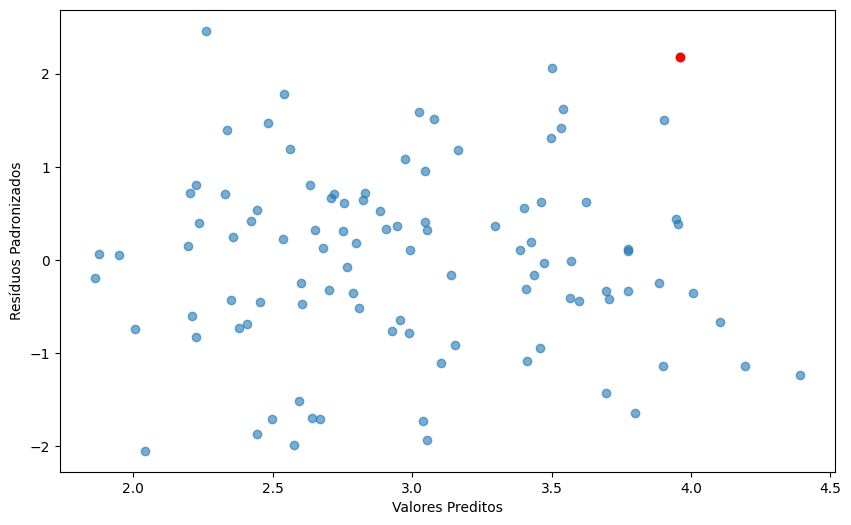

In [92]:
def plot_previsoes_residuos(res):
    indice_outlier = 100
    ax = subplots(figsize=(10, 6))[1]
    ax.scatter(res.fittedvalues, res.resid/np.sqrt(res.scale), alpha=0.6)
    ax.scatter(res.fittedvalues[indice_outlier], (res.resid/np.sqrt(res.scale))[indice_outlier], color='red')
    ax.set_xlabel('Valores Preditos')
    ax.set_ylabel('Resíduos Padronizados')

plot_previsoes_residuos(resultados_14_c_g)

O modelo original teve um altíssimo valor de alavancagem. o Resultado de Y teve um erro alto, porém não foi o maior dentre os preditos

R2: 0.21687081476133252
         intercept     x1
coef        2.0739  1.876
std err     0.2010  0.358
t          10.3100  5.236
P>|t|       0.0000  0.000


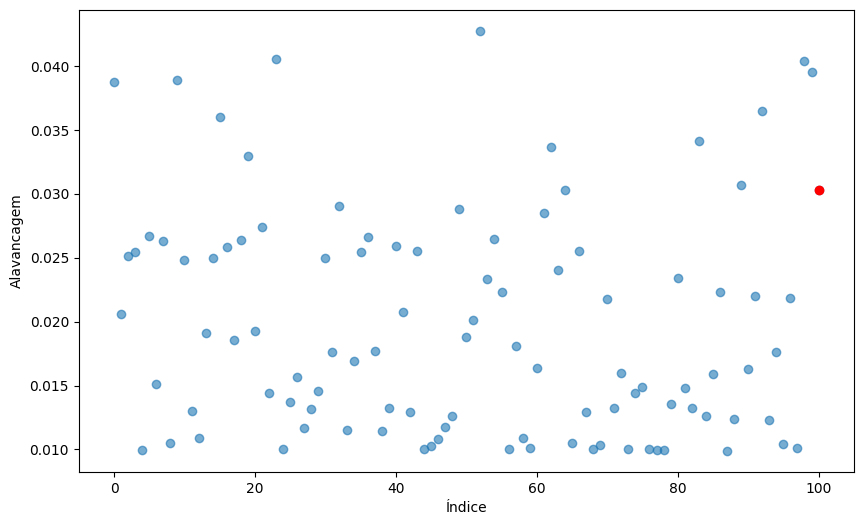

In [93]:
resultados_14_d_g = sm.OLS(y, MS(['x1']).fit_transform(df)).fit()
print('R2:', resultados_14_d_g.rsquared)
print(summarize(resultados_14_d_g).T)

plot_hat_matrix_diag(resultados_14_d_g)

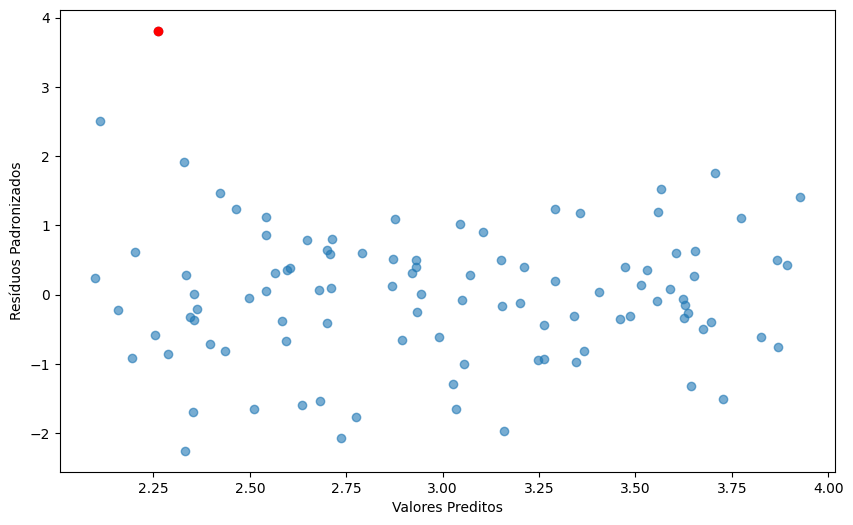

In [94]:
plot_previsoes_residuos(resultados_14_d_g)

O modelo com 'X1' teve um valor de alavancagem dentro dos padrões do modelo. o Resultado de Y teve um erro alto, sendo o maior dentre os preditos

R2: 0.26720095626012963
         intercept      x2
coef         2.284  3.1458
std err      0.151  0.5240
t           15.088  6.0080
P>|t|        0.000  0.0000


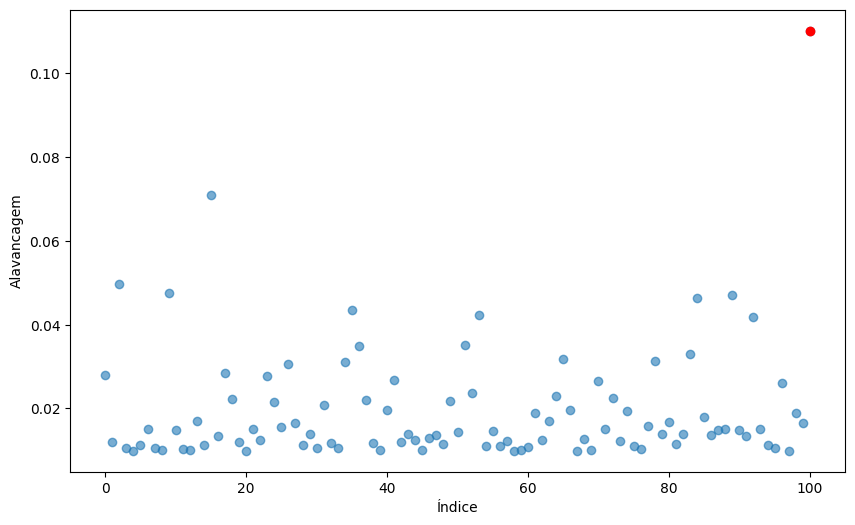

In [95]:
resultados_14_e_g = sm.OLS(y, MS(['x2']).fit_transform(df)).fit()
print('R2:', resultados_14_e_g.rsquared)
print(summarize(resultados_14_e_g).T)
plot_hat_matrix_diag(resultados_14_e_g)

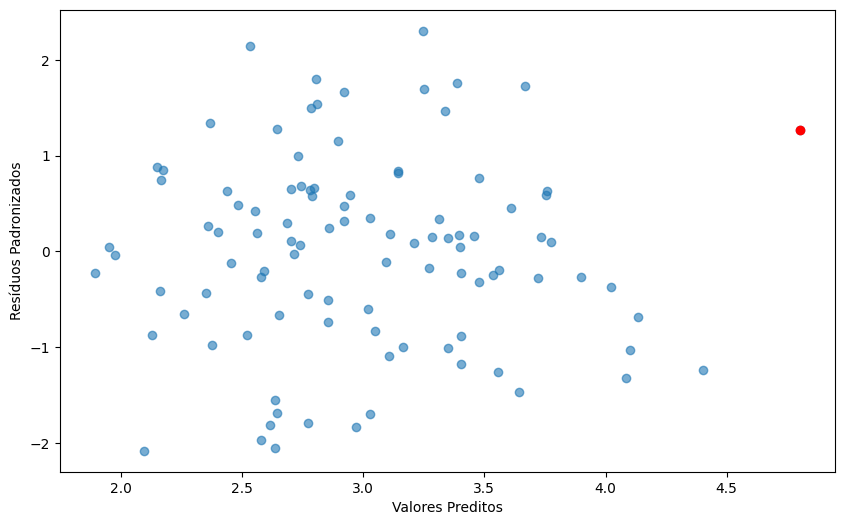

In [96]:
plot_previsoes_residuos(resultados_14_e_g)

O modelo com 'X2' teve um altíssimo valor de alavancagem. o Resultado de Y teve um erro dentro dos limites do modelo